# Влияние BTC на ADA: лаги, накопленное движение и экстремальные события

Исследование использует **простые относительные доходности**: $r_t=P_t/P_{t-k}-1$.

Положительный лаг $\tau$ в $corr(r^{BTC}_t, r^{ADA}_{t+\tau})$ означает, что BTC опережает ADA. По умолчанию выполняется тест на первом общем дне; после проверки можно переключиться на все данные.

In [2]:
import io
import os
import re
from concurrent.futures import ThreadPoolExecutor

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

TEST_MODE = False
TEST_DATE = "2020-02-01"
FULL_START_DATE = None  # None = самая ранняя доступная дата
FULL_END_DATE = None    # None = самая поздняя доступная дата
MAX_WORKERS = 16
LAGS = range(-10, 11)
EVENT_HORIZONS = range(1, 11)

load_dotenv()
required_env = ["YC_ENDPOINT", "YC_REGION", "YC_ACCESS_KEY_ID", "YC_SECRET_ACCESS_KEY"]
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise RuntimeError("Не настроен доступ к S3: " + ", ".join(missing_env))

BUCKET = os.getenv("YC_BUCKET", "binance-data-downloader")
s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("YC_ENDPOINT"),
    region_name=os.getenv("YC_REGION"),
    aws_access_key_id=os.getenv("YC_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("YC_SECRET_ACCESS_KEY"),
)

In [3]:
DATE_RE = re.compile(r"/date=(\d{4}-\d{2}-\d{2})/")

def list_kline_keys(symbol, start_date=None, end_date=None):
    base_prefix = f"raw/klines/symbol={symbol}/interval=1m/"
    if start_date is not None and start_date == end_date:
        prefix = f"{base_prefix}date={start_date}/"
    else:
        prefix = base_prefix

    keys = []
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            match = DATE_RE.search(f"/{key}")
            if not match or not key.endswith(".parquet"):
                continue
            date = match.group(1)
            if start_date is not None and date < start_date:
                continue
            if end_date is not None and date > end_date:
                continue
            keys.append(key)
    return sorted(keys)

def read_close(key):
    body = s3.get_object(Bucket=BUCKET, Key=key)["Body"].read()
    return pd.read_parquet(io.BytesIO(body), columns=["timestamp", "close"])

def load_symbol(symbol, start_date=None, end_date=None):
    keys = list_kline_keys(symbol, start_date, end_date)
    if not keys:
        raise FileNotFoundError(f"Не найдены данные {symbol} за выбранный период")
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        parts = list(executor.map(read_close, keys))
    frame = pd.concat(parts, ignore_index=True)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)
    frame["close"] = pd.to_numeric(frame["close"], errors="coerce")
    frame = frame.dropna().drop_duplicates("timestamp").sort_values("timestamp")
    return frame.set_index("timestamp")["close"].rename(symbol), keys


In [4]:
if TEST_MODE:
    start_date = end_date = TEST_DATE
else:
    start_date, end_date = FULL_START_DATE, FULL_END_DATE

btc_close, btc_keys = load_symbol("BTCUSDT", start_date, end_date)
ada_close, ada_keys = load_symbol("ADAUSDT", start_date, end_date)

prices = pd.concat([btc_close, ada_close], axis=1, join="inner").sort_index()
minute_index = pd.date_range(prices.index.min(), prices.index.max(), freq="min", tz="UTC")
prices = prices.reindex(minute_index)
prices.index.name = "timestamp"

print(f"Режим: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Период: {prices.index.min()} — {prices.index.max()}")
print(f"Файлов BTC / ADA: {len(btc_keys)} / {len(ada_keys)}")
print(f"Минут в сетке: {len(prices):,}; полных пар: {prices.notna().all(axis=1).sum():,}")
prices.head()

Режим: FULL
Период: 2020-02-01 00:00:00+00:00 — 2026-02-01 23:59:00+00:00
Файлов BTC / ADA: 2193 / 2194
Минут в сетке: 3,157,920; полных пар: 3,157,920


,BTCUSDT,ADAUSDT
timestamp,,
2020-02-01 00:00:00+00:00,9371.839844,0.05382
2020-02-01 00:01:00+00:00,9372.580078,0.05381
2020-02-01 00:02:00+00:00,9369.530273,0.05377
2020-02-01 00:03:00+00:00,9367.870117,0.05378
2020-02-01 00:04:00+00:00,9361.200195,0.05368


In [5]:
returns = pd.DataFrame(index=prices.index)
returns["btc_1m"] = prices["BTCUSDT"].pct_change(1, fill_method=None)
returns["btc_5m"] = prices["BTCUSDT"].pct_change(5, fill_method=None)
returns["btc_10m"] = prices["BTCUSDT"].pct_change(10, fill_method=None)
returns["ada_1m"] = prices["ADAUSDT"].pct_change(1, fill_method=None)
returns.describe()

,btc_1m,btc_5m,btc_10m,ada_1m
count,3.157919e+06,3.157915e+06,3.157910e+06,3.157919e+06
mean,1.105787e-06,5.425352e-06,1.069640e-05,1.788209e-06
std,9.371249e-04,2.043956e-03,2.836659e-03,1.585678e-03
min,-7.077223e-02,-1.261181e-01,-1.707878e-01,-2.188513e-01
25%,-3.279448e-04,-7.135272e-04,-9.897947e-04,-5.964637e-04
50%,0.000000e+00,0.000000e+00,3.695488e-06,0.000000e+00
75%,3.263950e-04,7.218122e-04,1.011610e-03,5.968809e-04
max,7.292068e-02,1.763668e-01,2.155582e-01,1.738054e-01


## Исследование 1. Кросс-корреляция минутных доходностей

$corr(r^{BTC}_{1m,t}, r^{ADA}_{1m,t+\tau})$, где $\tau\in[-10,10]$.

Максимум по модулю: {'lag_min': 0.0, 'correlation': 0.6414648773136872, 'n_obs': 3157919.0}


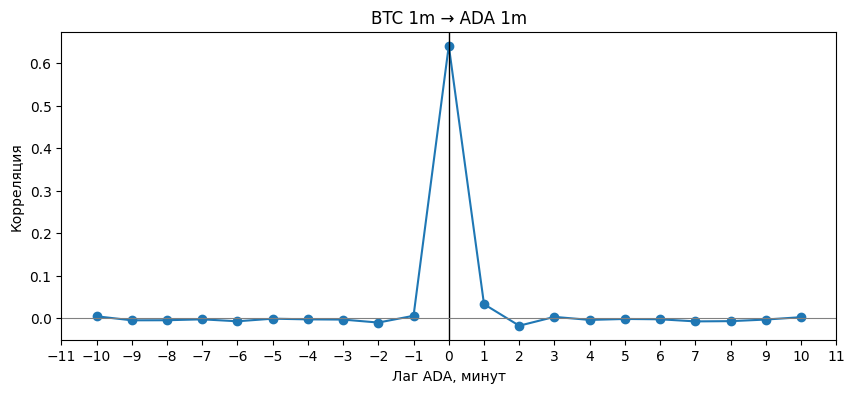

,lag_min,correlation,n_obs
0,-10,0.004074,3157909
1,-9,-0.005406,3157910
2,-8,-0.005228,3157911
3,-7,-0.003095,3157912
4,-6,-0.007712,3157913
5,-5,-0.001565,3157914
6,-4,-0.003207,3157915
7,-3,-0.003685,3157916
8,-2,-0.010719,3157917
9,-1,0.005223,3157918


In [6]:
def lag_correlations(btc_returns, ada_returns, lags=LAGS):
    rows = []
    for tau in lags:
        aligned = pd.concat(
            [btc_returns.rename("btc"), ada_returns.shift(-tau).rename("ada_future")],
            axis=1,
        ).dropna()
        rows.append({
            "lag_min": tau,
            "correlation": aligned["btc"].corr(aligned["ada_future"]),
            "n_obs": len(aligned),
        })
    return pd.DataFrame(rows)

from matplotlib.ticker import MultipleLocator
corr_1m = lag_correlations(returns["btc_1m"], returns["ada_1m"])
best_1m = corr_1m.loc[corr_1m["correlation"].abs().idxmax()]
print("Максимум по модулю:", best_1m.to_dict())

ax = corr_1m.plot(
    x="lag_min",
    y="correlation",
    marker="o",
    figsize=(10, 4),
    legend=False
)

ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)

# целые числа с шагом 1
ax.xaxis.set_major_locator(MultipleLocator(1))

ax.set(
    title="BTC 1m → ADA 1m",
    xlabel="Лаг ADA, минут",
    ylabel="Корреляция"
)

plt.show()
corr_1m

## Исследование 2. Накопленное движение BTC

Сравниваем будущую минутную доходность ADA с простыми доходностями BTC за 5 и 10 минут.

 lag_min  correlation   n_obs btc_window
      -8     0.213243 3157910        10m
      -3     0.304879 3157915         5m


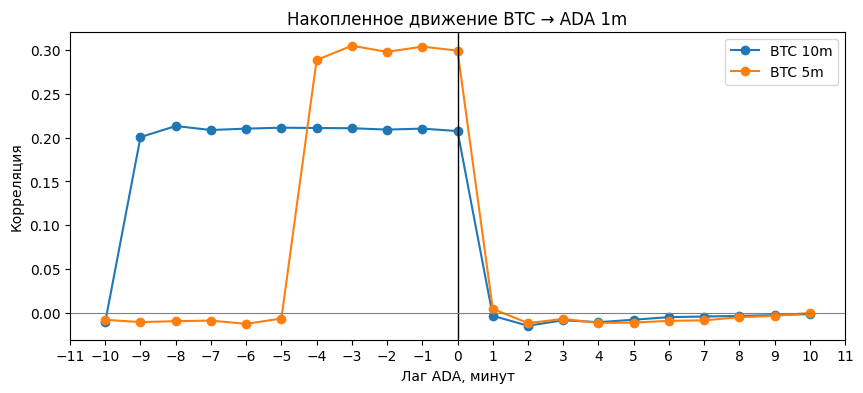

,lag_min,correlation,n_obs,btc_window
0,-10,-0.007897,3157909,5m
1,-9,-0.010487,3157910,5m
2,-8,-0.009436,3157911,5m
3,-7,-0.008789,3157912,5m
4,-6,-0.012486,3157913,5m
5,-5,-0.006414,3157914,5m
6,-4,0.288605,3157915,5m
7,-3,0.304879,3157915,5m
8,-2,0.297850,3157915,5m
9,-1,0.303877,3157915,5m


In [7]:
corr_5m = lag_correlations(returns["btc_5m"], returns["ada_1m"]).assign(btc_window="5m")
corr_10m = lag_correlations(returns["btc_10m"], returns["ada_1m"]).assign(btc_window="10m")
corr_cumulative = pd.concat([corr_5m, corr_10m], ignore_index=True)

best_cumulative = (
    corr_cumulative.loc[corr_cumulative.groupby("btc_window")["correlation"].apply(lambda s: s.abs().idxmax())]
    .sort_values("btc_window")
)
print(best_cumulative.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))

for window, group in corr_cumulative.groupby("btc_window"):
    ax.plot(group["lag_min"], group["correlation"],
            marker="o", label=f"BTC {window}")

ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)

# целые значения с шагом 1
ax.xaxis.set_major_locator(MultipleLocator(1))

ax.set(
    title="Накопленное движение BTC → ADA 1m",
    xlabel="Лаг ADA, минут",
    ylabel="Корреляция"
)

ax.legend()
plt.show()
corr_cumulative

## Исследование 3. Экстремальные движения BTC

События: `BTC 1m > 0.5%`, `BTC 5m > 1%` и объединение условий. Для каждой следующей минуты оцениваются средняя доходность ADA и 95% нормальный доверительный интервал. Соседние сигнальные минуты считаются отдельными событиями.

Число исходных событий:
  BTC 1m > 0.5%: 5219
  BTC 5m > 1%: 6889
  Любое условие: 10261


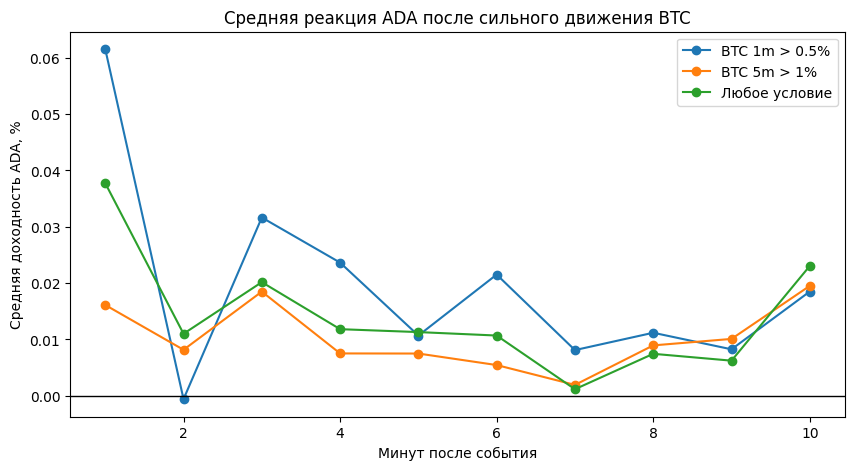

,horizon_min,mean_ada_return,median_ada_return,ci95_low,ci95_high,n_events,trigger
0,1,0.000615,0.000074,0.000368,0.000862,5219,BTC 1m > 0.5%
1,2,-0.000006,-0.000097,-0.000239,0.000228,5219,BTC 1m > 0.5%
2,3,0.000316,0.000063,0.000092,0.000541,5219,BTC 1m > 0.5%
3,4,0.000236,0.000000,0.000039,0.000434,5219,BTC 1m > 0.5%
4,5,0.000107,0.000000,-0.000114,0.000328,5219,BTC 1m > 0.5%
5,6,0.000215,0.000000,0.000011,0.000419,5219,BTC 1m > 0.5%
6,7,0.000081,0.000000,-0.000113,0.000275,5219,BTC 1m > 0.5%
7,8,0.000112,0.000000,-0.000089,0.000313,5219,BTC 1m > 0.5%
8,9,0.000083,0.000000,-0.000110,0.000275,5219,BTC 1m > 0.5%
9,10,0.000185,0.000029,-0.000013,0.000383,5219,BTC 1m > 0.5%


In [8]:
event_masks = {
    "BTC 1m > 0.5%": returns["btc_1m"] > 0.005,
    "BTC 5m > 1%": returns["btc_5m"] > 0.01,
}
event_masks["Любое условие"] = event_masks["BTC 1m > 0.5%"] | event_masks["BTC 5m > 1%"]

def event_response(mask, ada_returns=returns["ada_1m"], horizons=EVENT_HORIZONS):
    rows = []
    for tau in horizons:
        sample = ada_returns.shift(-tau)[mask].dropna()
        mean = sample.mean()
        sem = sample.std(ddof=1) / np.sqrt(len(sample)) if len(sample) > 1 else np.nan
        rows.append({
            "horizon_min": tau,
            "mean_ada_return": mean,
            "median_ada_return": sample.median(),
            "ci95_low": mean - 1.96 * sem,
            "ci95_high": mean + 1.96 * sem,
            "n_events": len(sample),
        })
    return pd.DataFrame(rows)

event_results = pd.concat(
    [event_response(mask).assign(trigger=name) for name, mask in event_masks.items()],
    ignore_index=True,
)
print("Число исходных событий:")
for name, mask in event_masks.items():
    print(f"  {name}: {int(mask.sum())}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, group in event_results.groupby("trigger", sort=False):
    ax.plot(group["horizon_min"], 100 * group["mean_ada_return"], marker="o", label=name)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Средняя реакция ADA после сильного движения BTC", xlabel="Минут после события", ylabel="Средняя доходность ADA, %")
ax.legend()
plt.show()
event_results

# Анализ с целевой переменной

Цель — будущая логарифмическая доходность ADA за 10 минут:

$$y_t = \ln\left(\frac{P^{ADA}_{t+10}}{P^{ADA}_t}\right).$$

Диагностически рассматриваются лаги $[-10,10]$, но прогнозными считаются только $\tau\geq0$: отрицательные лаги создают временное перекрытие целевого окна с наблюдением BTC.

In [9]:
ada_target_10m = np.log(
    prices["ADAUSDT"].shift(-10) / prices["ADAUSDT"]
).rename("ada_forward_log_return_10m")

print(ada_target_10m.describe())
ada_target_10m.dropna().head()

count    3.157910e+06
mean     5.293258e-06
std      4.915969e-03
min     -9.536484e-01
25%     -1.863546e-03
50%      0.000000e+00
75%      1.876143e-03
max      5.297143e-01
Name: ada_forward_log_return_10m, dtype: float64


timestamp
2020-02-01 00:00:00+00:00    0.000929
2020-02-01 00:01:00+00:00    0.002598
2020-02-01 00:02:00+00:00    0.003342
2020-02-01 00:03:00+00:00    0.002971
2020-02-01 00:04:00+00:00    0.005388
Freq: min, Name: ada_forward_log_return_10m, dtype: float32

## Цель 1. BTC 1m и будущая доходность ADA за 10 минут

Диагностический максимум: {'lag_min': -9.0, 'correlation': 0.20748943568495623, 'n_obs': 3157910.0}
Лучший прогнозный лаг (tau >= 0): {'lag_min': 1.0, 'correlation': -0.01349985720484049, 'n_obs': 3157908.0}


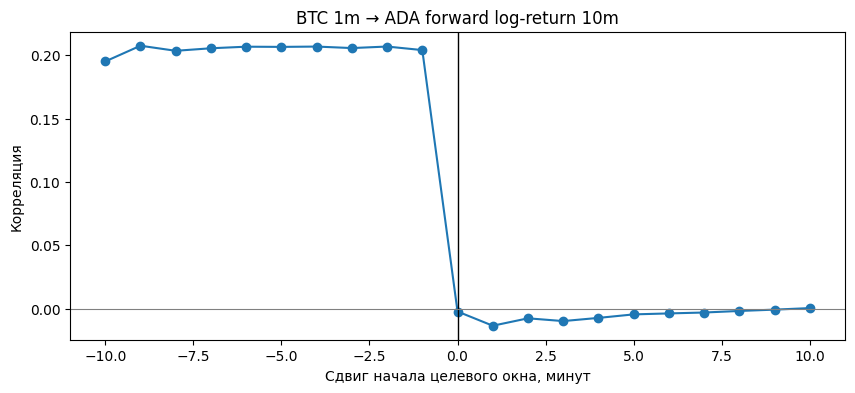

,lag_min,correlation,n_obs
0,-10,0.195083,3157910
1,-9,0.207489,3157910
2,-8,0.203482,3157910
3,-7,0.205481,3157910
4,-6,0.206723,3157910
5,-5,0.206569,3157910
6,-4,0.206822,3157910
7,-3,0.205641,3157910
8,-2,0.206843,3157910
9,-1,0.204044,3157910


In [10]:
target_corr_1m = lag_correlations(returns["btc_1m"], ada_target_10m)
target_best_1m = target_corr_1m.loc[target_corr_1m["correlation"].abs().idxmax()]
target_predictive_1m = target_corr_1m.query("lag_min >= 0")
target_best_predictive_1m = target_predictive_1m.loc[target_predictive_1m["correlation"].abs().idxmax()]
print("Диагностический максимум:", target_best_1m.to_dict())
print("Лучший прогнозный лаг (tau >= 0):", target_best_predictive_1m.to_dict())

ax = target_corr_1m.plot(x="lag_min", y="correlation", marker="o", figsize=(10, 4), legend=False)
ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set(title="BTC 1m → ADA forward log-return 10m", xlabel="Сдвиг начала целевого окна, минут", ylabel="Корреляция")
plt.show()
target_corr_1m

## Цель 2. Накопленные доходности BTC и будущая доходность ADA

Лучшие прогнозные лаги (tau >= 0):
 lag_min  correlation   n_obs btc_window
       0    -0.017582 3157900        10m
       1    -0.019423 3157904         5m


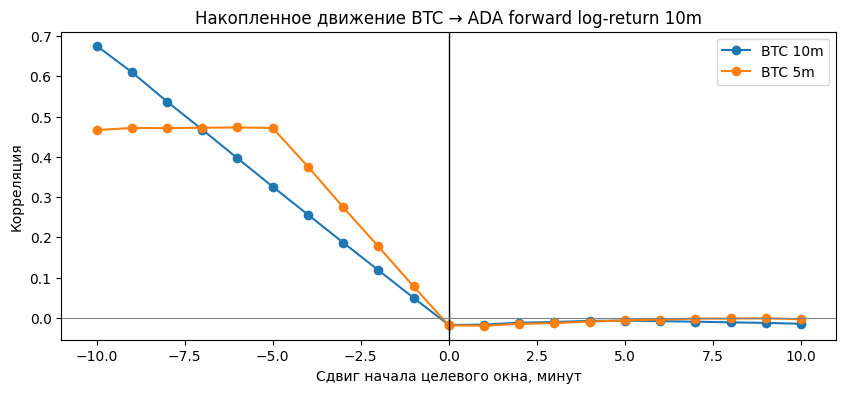

,lag_min,correlation,n_obs,btc_window
0,-10,0.466537,3157910,5m
1,-9,0.471736,3157910,5m
2,-8,0.471358,3157910,5m
3,-7,0.472346,3157910,5m
4,-6,0.473034,3157910,5m
5,-5,0.471819,3157910,5m
6,-4,0.376040,3157909,5m
7,-3,0.275043,3157908,5m
8,-2,0.177398,3157907,5m
9,-1,0.078205,3157906,5m


In [11]:
target_corr_5m = lag_correlations(returns["btc_5m"], ada_target_10m).assign(btc_window="5m")
target_corr_10m = lag_correlations(returns["btc_10m"], ada_target_10m).assign(btc_window="10m")
target_corr_cumulative = pd.concat([target_corr_5m, target_corr_10m], ignore_index=True)
target_predictive_cumulative = target_corr_cumulative.query("lag_min >= 0")
target_best_cumulative = (
    target_predictive_cumulative.loc[
        target_predictive_cumulative.groupby("btc_window")["correlation"].apply(lambda s: s.abs().idxmax())
    ].sort_values("btc_window")
)
print("Лучшие прогнозные лаги (tau >= 0):")
print(target_best_cumulative.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
for window, group in target_corr_cumulative.groupby("btc_window"):
    ax.plot(group["lag_min"], group["correlation"], marker="o", label=f"BTC {window}")
ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set(title="Накопленное движение BTC → ADA forward log-return 10m", xlabel="Сдвиг начала целевого окна, минут", ylabel="Корреляция")
ax.legend()
plt.show()
target_corr_cumulative

## Цель 3. Целевая переменная после экстремальных движений BTC

Для каждого события оценивается $E(y_{t+\tau})$ на горизонтах $\tau=1,\ldots,10$.

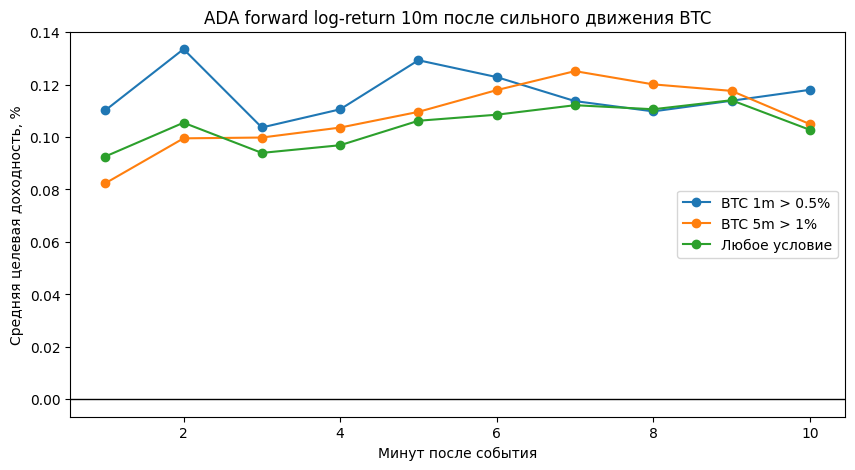

,horizon_min,mean_target,median_target,ci95_low,ci95_high,n_events,trigger
0,1,0.001102,0.000209,0.000514,0.001690,5219,BTC 1m > 0.5%
1,2,0.001336,0.000324,0.000739,0.001932,5219,BTC 1m > 0.5%
2,3,0.001037,0.000252,0.000467,0.001606,5219,BTC 1m > 0.5%
3,4,0.001106,0.000372,0.000564,0.001647,5219,BTC 1m > 0.5%
4,5,0.001293,0.000474,0.000753,0.001834,5219,BTC 1m > 0.5%
5,6,0.001229,0.000476,0.000708,0.001750,5219,BTC 1m > 0.5%
6,7,0.001137,0.000535,0.000638,0.001637,5219,BTC 1m > 0.5%
7,8,0.001098,0.000444,0.000594,0.001602,5219,BTC 1m > 0.5%
8,9,0.001139,0.000405,0.000638,0.001639,5219,BTC 1m > 0.5%
9,10,0.001180,0.000427,0.000688,0.001673,5219,BTC 1m > 0.5%


In [12]:
def target_event_response(mask, target=ada_target_10m, horizons=EVENT_HORIZONS):
    rows = []
    for tau in horizons:
        sample = target.shift(-tau)[mask].dropna()
        mean = sample.mean()
        sem = sample.std(ddof=1) / np.sqrt(len(sample)) if len(sample) > 1 else np.nan
        rows.append({
            "horizon_min": tau,
            "mean_target": mean,
            "median_target": sample.median(),
            "ci95_low": mean - 1.96 * sem,
            "ci95_high": mean + 1.96 * sem,
            "n_events": len(sample),
        })
    return pd.DataFrame(rows)

target_event_results = pd.concat(
    [target_event_response(mask).assign(trigger=name) for name, mask in event_masks.items()],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, group in target_event_results.groupby("trigger", sort=False):
    ax.plot(group["horizon_min"], 100 * group["mean_target"], marker="o", label=name)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="ADA forward log-return 10m после сильного движения BTC", xlabel="Минут после события", ylabel="Средняя целевая доходность, %")
ax.legend()
plt.show()
target_event_results

## Полный запуск

После успешного теста установите `TEST_MODE = False` и перезапустите все ячейки. При `FULL_START_DATE = FULL_END_DATE = None` будут использованы все доступные общие данные BTC и ADA. Загрузка нескольких тысяч дневных parquet может занять заметное время.

Корреляция сама по себе не доказывает причинность. Для итогового вывода нужно сравнить величину эффекта, знак лага, устойчивость на подпериодах и доверительные интервалы событийного анализа.